# Indoor Air Quality Prediction using LSTM

This notebook implements a Long Short-Term Memory (LSTM) network to predict Air Quality based on sensor data from `IAQ Baqubah Teaching Hospital .csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
file_path = "IAQ Baqubah Teaching Hospital .csv"
df = pd.read_csv(file_path)

# Convert Timestamp
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts')
df.set_index('ts', inplace=True)

# Handle eCO2
if 'eCO2' in df.columns and 'CO2' in df.columns:
    corr = df[['CO2', 'eCO2']].corr().iloc[0,1]
    if corr > 0.9:
        df = df.drop(columns=['eCO2'])
    else:
        df['eCO2'] = df['eCO2'].interpolate(method='linear').ffill().bfill()

df = df.ffill().bfill()
df.head()

,CO2,TVOC,PM10,PM2.5,eCO2,CO,Air Quality,LDR,O3,Temp,Hum
ts,,,,,,,,,,,
2024-05-22 12:13:00,425.000000,4.0,5.190,0.320000,588.0,357.0,42.000000,962.0,522.000000,26.300000,41.700000
2024-05-22 12:14:00,419.500000,26.5,5.240,0.260000,590.0,360.5,41.500000,962.0,521.500000,26.200000,41.650000
2024-05-22 12:15:00,420.666667,19.0,5.760,0.266667,556.0,360.0,41.333333,962.0,523.666667,26.133333,41.666667
2024-05-22 12:16:00,424.000000,15.5,5.765,0.292500,536.0,360.5,40.500000,962.0,524.750000,26.100000,41.650000
2024-05-22 12:50:00,419.200000,22.2,6.946,0.342000,666.5,357.2,40.400000,961.8,526.200000,25.920000,41.980000


## 2. Preprocessing for LSTM

In [3]:
# Select features and target
features = ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR']
if 'eCO2' in df.columns: features.append('eCO2')
target = 'PM2.5'

data = df[features + [target]].values

# Scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Split data (Time-based split is crucial for LSTM)
split_idx = int(len(data_scaled) * 0.8)
train_data = data_scaled[:split_idx]
test_data = data_scaled[split_idx:]

# Create sequences
n_input = 10 # Number of past time steps to look back
n_features = data_scaled.shape[1]
batch_size = 32

train_generator = TimeseriesGenerator(train_data, train_data[:, -1], length=n_input, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_data, test_data[:, -1], length=n_input, batch_size=batch_size)

## 3. Build LSTM Model

In [4]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_input, n_features)))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,451 (48.64 KB)

 Trainable params: 12,451 (48.64 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

In [5]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

Epoch 1/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 161s 12ms/step - loss: 0.0116 - val_loss: 0.0140
Epoch 2/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 106s 8ms/step - loss: 0.0091 - val_loss: 0.0142
Epoch 3/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 95s 7ms/step - loss: 0.0089 - val_loss: 0.0135
Epoch 4/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - loss: 0.0087 - val_loss: 0.0133
Epoch 5/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 136s 10ms/step - loss: 0.0087 - val_loss: 0.0136
Epoch 6/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 150s 11ms/step - loss: 0.0086 - val_loss: 0.0132
Epoch 7/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 136s 10ms/step - loss: 0.0086 - val_loss: 0.0132
Epoch 8/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 120s 9ms/step - loss: 0.0085 - val_loss: 0.0133
Epoch 9/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 158s 12ms/step - loss: 0.0085 - val_loss: 0.0132
Epoch 10/10
13088/13088 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - loss: 0.0085 - val_loss: 0.0129


## 5. Evaluation

3272/3272 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0129
Test Loss (MSE): 0.012859649956226349


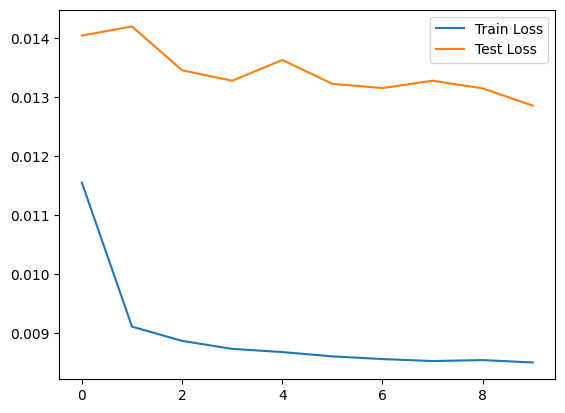

In [6]:
loss = model.evaluate(test_generator)
print(f"Test Loss (MSE): {loss}")

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.show()

3272/3272 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step


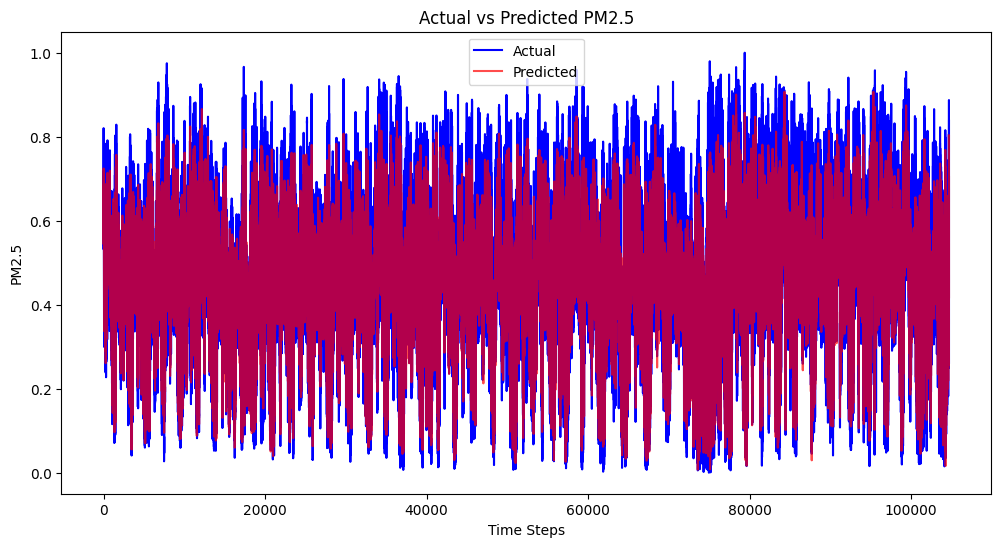

In [7]:
# Plot Actual vs Predicted
# Adjust actuals to match prediction length (n_input offset)
actuals = test_generator.targets[n_input:]
predictions = model.predict(test_generator)

plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Actual', color='blue')
plt.plot(predictions, label='Predicted', color='red', alpha=0.7)
plt.title(f'Actual vs Predicted PM2.5')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

3272/3272 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step
3272/3272 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step


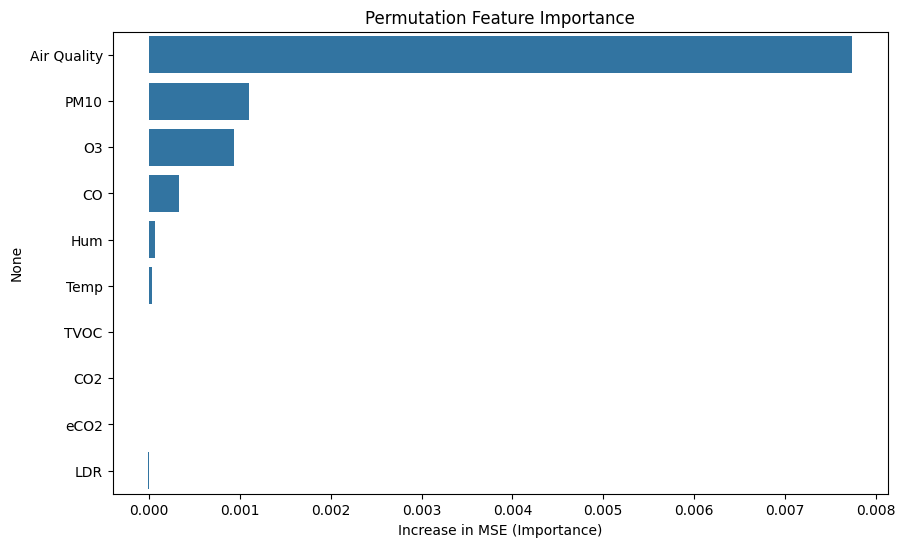

In [8]:
# Permutation Feature Importance (Perturbation on Test Data)
def calculate_permutation_importance(model, data, n_input, batch_size, features):
    # data is the scaled test_data array
    baseline_gen = TimeseriesGenerator(data, data[:, -1], length=n_input, batch_size=batch_size)
    baseline_pred = model.predict(baseline_gen)
    
    # Align targets
    baseline_targets = baseline_gen.targets[n_input:]
    # Ensure lengths match exactly (sometimes generator drops last batch if not divisible? No, TimeseriesGenerator handles it)
    min_len = min(len(baseline_targets), len(baseline_pred))
    baseline_targets = baseline_targets[:min_len]
    baseline_pred = baseline_pred[:min_len]
    
    baseline_mse = mean_squared_error(baseline_targets, baseline_pred)
    
    importances = {}
    
    for i, feature in enumerate(features):
        # Create a copy and shuffle the feature column
        data_copy = data.copy()
        np.random.shuffle(data_copy[:, i])
        
        # Create generator with shuffled feature
        shuffled_gen = TimeseriesGenerator(data_copy, data_copy[:, -1], length=n_input, batch_size=batch_size)
        shuffled_pred = model.predict(shuffled_gen)
        
        # Align targets for shuffled data
        shuffled_targets = shuffled_gen.targets[n_input:]
        shuffled_targets = shuffled_targets[:min_len]
        shuffled_pred = shuffled_pred[:min_len]
        
        shuffled_mse = mean_squared_error(shuffled_targets, shuffled_pred)
        
        # Importance = Increase in MSE
        importances[feature] = shuffled_mse - baseline_mse
    
    return pd.Series(importances).sort_values(ascending=False)

# Calculate and Plot
importance = calculate_permutation_importance(model, test_data, n_input, batch_size, features)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index)
plt.title(f'Permutation Feature Importance')
plt.xlabel('Increase in MSE (Importance)')
plt.show()

In [9]:
# Standardized Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure 1D arrays for metrics
y_true_metrics = actuals.flatten()
y_pred_metrics = predictions.flatten()

mse = mean_squared_error(y_true_metrics, y_pred_metrics)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_metrics, y_pred_metrics)
r2 = r2_score(y_true_metrics, y_pred_metrics)

print('Performance Metrics:')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')

Performance Metrics:
RMSE: 0.1134
MAE:  0.0797
R2:   0.5889
